# Polynomial Regression and Regularization

## When a cart speeds up

A cart that speeds up travels farther in each second. A straight line adds the same distance every second, so it may miss the curvature. A quadratic model also includes time multiplied by itself:

$$\text{distance}=b+a\times t+c\times t\times t.$$

Here $t$ is time in seconds. The coefficients $b$, $a$, and $c$ set the starting distance, the straight-line term, and the curved term. For the simulated mean motion:

$$\text{distance}=2+1.2\times t+0.3\times t\times t.$$

At 3 seconds, this gives $2+1.2\times3+0.3\times3\times3=2+3.6+2.7=8.3$ m. Actual measured dots include noise.

<img src="https://raw.githubusercontent.com/sonamu-jun/introduction-to-ai-convergence/main/06-1_Regression/assets/04_fitting_a_curve.png" alt="The same cart measurements compared with a straight line, a quadratic curve, and a degree-12 curve." width="640" style="max-width:100%;height:auto;">

A cubic adds a $t\times t\times t$ term. Higher degrees add still longer products. These models are curved in time but remain linear in their unknown coefficients: each coefficient multiplies a known feature. Ordinary least squares can therefore fit them.

## A smooth trend or a curve that follows noise

The experiment has 18 training measurements between 0 and 6 s. A line may miss the curved trend: underfitting. A degree-12 polynomial may bend to follow small measurement errors: overfitting. Separate validation points show whether that extra bending improves predictions.

Regularization adds a cost for large coefficients. If three feature coefficients are $u$, $v$, and $w$, Ridge adds:

$$\text{Ridge penalty}=\text{strength}\times(u^2+v^2+w^2).$$

For coefficients 2, −3, and 1, and strength 0.1, this becomes $0.1\times(4+9+1)=1.4$. This penalty is added to the squared-error fitting cost. Ridge is also called L2 regularization. Lasso, or L1 regularization, uses $\text{strength}\times(|u|+|v|+|w|)$ instead and can make some coefficients zero. Elastic Net combines both kinds of penalty.

The intercept is not penalized here. Features are scaled using training data so that their numerical sizes are comparable. This scaling changes the feature units; regularization discourages large fitted coefficients. Too much penalty can also underfit.

The controls change the degree and Ridge strength. Filled dots are observations; open dots on the curve are predictions at the training times. Training points set the coefficients. Validation points compare model choices. Test points are reserved for the later evaluation.

The later test comparison uses the best of four predefined candidates: a line, a quadratic, a degree-12 polynomial, and a degree-12 Ridge model. That validation choice stays fixed while the exploratory controls change.

,Train RMSE (m),Validation RMSE (m)
Model,,
Linear,1.218,1.147
Quadratic,0.960,0.807
Degree 12,0.666,1.744
Degree 12 + Ridge,1.077,0.877


Frozen validation choice: Quadratic


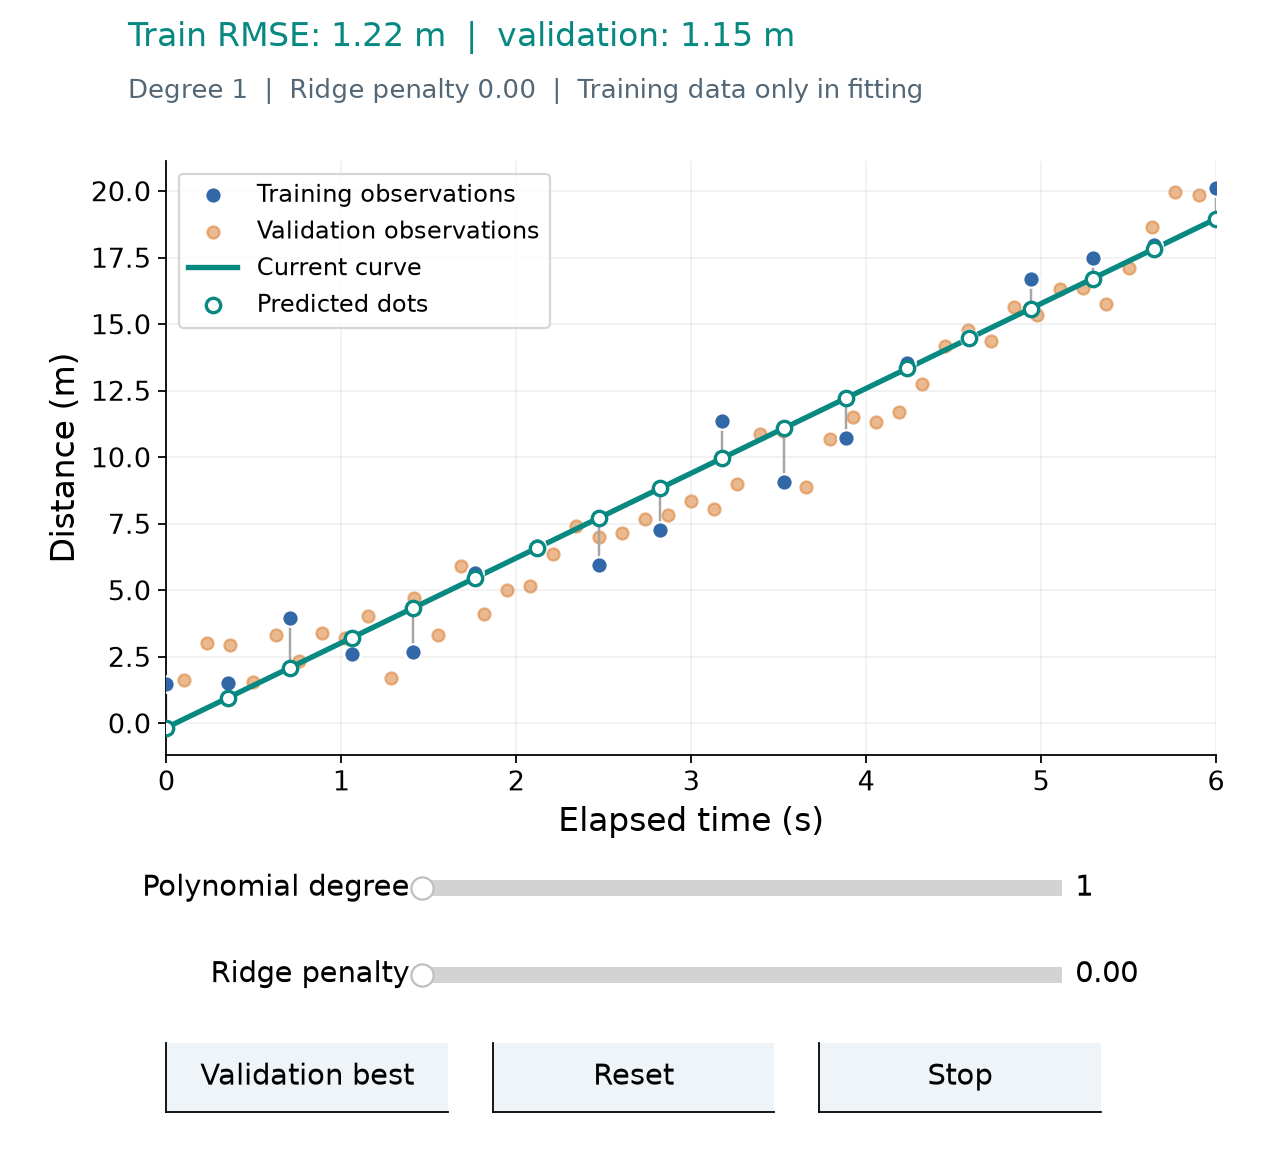

In [1]:
import os
import sys
import io
import base64
from pathlib import Path
from tempfile import gettempdir
import numpy as np
import pandas as pd
import matplotlib

REGRESSION_STATIC = os.environ.get("REGRESSION_STATIC") == "1"
REGRESSION_BROWSER = sys.platform == "emscripten"
if not REGRESSION_STATIC and not REGRESSION_BROWSER:
    from IPython import get_ipython
    shell = get_ipython()
    if shell is not None and getattr(shell, "kernel", None) is not None:
        shell.run_line_magic("matplotlib", "widget")

import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.widgets import Slider, Button
from matplotlib.patches import Rectangle
from IPython.display import Image, display
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# Bundle the required DejaVu Sans characters for offline browser rendering.
_regression_font = Path(gettempdir()) / "regression-lecture-font.ttf"
_regression_font_data = base64.b64decode("...")
if not _regression_font.exists() or _regression_font.read_bytes() != _regression_font_data:
    _regression_font.write_bytes(_regression_font_data)
font_manager.fontManager.addfont(str(_regression_font))
plt.rcParams.update({
    "font.family": font_manager.FontProperties(fname=str(_regression_font)).get_name(),
    "font.size": 15, "axes.labelsize": 15,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.18, "lines.linewidth": 2.4,
    "axes.unicode_minus": False, "figure.facecolor": "white",
})
BLUE, TEAL, ORANGE, PURPLE = "#3268a8", "#078880", "#d87522", "#8251ac"


def metrics(observed, predicted):
    """R² is undefined for a constant evaluation target."""
    observed = np.asarray(observed, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    error = observed - predicted
    mse = np.mean(error**2)
    total = np.sum((observed - observed.mean())**2)
    return {"MAE": np.mean(np.abs(error)), "MSE": mse,
            "RMSE": np.sqrt(mse),
            "R²": 1 - np.sum(error**2) / total if total > 0 else np.nan}


# Close earlier views before replacing models or shared callbacks on a rerun.
for _previous_view in globals().get("_regression_views", {}).values():
    _previous_view.close()
_regression_views = {}


class RegressionExplorer:
    """Sliders redraw the model and its metrics from the same observations."""

    def __init__(self, name, render, sliders, actions=(), history=False):
        previous = _regression_views.get(name)
        if previous is not None:
            previous.close()
        self.render = render
        self.running = False
        self.controls, self.buttons, self.state = {}, {}, {}
        self.defaults = {key: initial for key, label, low, high, initial, step, fmt in sliders}
        # 80 dpi gives a 640 px live canvas; saved output uses 160 dpi at the same display size.
        with plt.ioff():
            self.figure = plt.figure(figsize=(8, 8.4 if history else 7.2), dpi=80)
        self.status = self.figure.text(.10, .96, "", fontsize=15, color=TEAL)
        self.detail = self.figure.text(.10, .915, "", fontsize=11.5, color="#536675")
        bottom = .27 + .075 * (len(sliders) - 1)
        if history:
            self.ax = self.figure.add_axes([.13, .56, .82, .30])
            self.history_ax = self.figure.add_axes([.13, .33, .82, .12])
        else:
            self.ax = self.figure.add_axes([.13, bottom, .82, .86 - bottom])
        for i, (key, label, low, high, initial, step, fmt) in enumerate(sliders):
            y = .14 + .075 * (len(sliders) - i - 1)
            slider = Slider(self.figure.add_axes([.33, y, .50, .028]),
                            label, low, high, valinit=initial, valstep=step,
                            valfmt=fmt, color=TEAL)
            slider.label.set_fontsize(13)
            slider.valtext.set_fontsize(13)
            slider.on_changed(self.update)
            self.controls[key] = slider
        commands = list(actions) + [("Reset", lambda view: view.reset()),
                                    ("Stop", lambda view: view.stop())]
        width = min(.22, .8 / len(commands) - .025)
        for i, (label, callback) in enumerate(commands):
            button = Button(self.figure.add_axes([.13 + i*(width+.035), .035, width, .06]),
                            label, color="#eef4f7", hovercolor="#d7e9e6")
            button.label.set_fontsize(13)
            button.on_clicked(lambda event, callback=callback: callback(self))
            self.buttons[label] = button
        self.figure.canvas.mpl_connect("close_event", lambda event: self.stop())
        _regression_views[name] = self
        self.update()

    def update(self, _=None):
        self.ax.clear()
        if hasattr(self, "history_ax"):
            self.history_ax.clear()
        values = {key: slider.val for key, slider in self.controls.items()}
        self.state = self.render(self, **values)
        self.figure.canvas.draw_idle()

    def set_values(self, **values):
        for key, value in values.items():
            slider = self.controls[key]
            events, drawing = slider.eventson, slider.drawon
            slider.eventson = slider.drawon = False
            slider.set_val(value)
            slider.eventson, slider.drawon = events, drawing
        self.update()

    def reset(self):
        self.set_values(**self.defaults)

    def start(self):
        if REGRESSION_STATIC:
            buffer = io.BytesIO()
            self.figure.savefig(buffer, format="png", dpi=160, facecolor="white")
            display(Image(data=buffer.getvalue(), width=640,
                          alt=self.status.get_text() + ". " + self.detail.get_text()))
            plt.close(self.figure)
            return
        self.running = True
        if REGRESSION_BROWSER:
            plt.show()
            try:
                while self.running and plt.fignum_exists(self.figure.number):
                    plt.pause(.04)
            finally:
                self.stop()
        elif hasattr(self.figure.canvas, "toolbar_visible"):
            self.figure.canvas.toolbar_visible = False
            self.figure.canvas.header_visible = False
            self.figure.canvas.footer_visible = False
            self.figure.canvas.resizable = False
            display(self.figure.canvas)
        else:
            plt.show()

    def stop(self):
        self.running = False
        for slider in self.controls.values():
            slider.set_active(False)
        for button in self.buttons.values():
            button.set_active(False)
        self.buttons["Stop"].label.set_text("Stopped")
        self.figure.canvas.draw_idle()

    def close(self):
        self.stop()
        plt.close(self.figure)


rng_cart = np.random.default_rng(61)


def cart_mean(time):
    time = np.asarray(time)
    return 2 + 1.2 * time + 0.3 * time**2


time_train = np.linspace(0, 6, 18)
distance_train = cart_mean(time_train) + rng_cart.normal(0, 0.9, len(time_train))
time_valid = np.linspace(0.1, 5.9, 45)
distance_valid = cart_mean(time_valid) + rng_cart.normal(0, 0.9, len(time_valid))


def polynomial_model(degree, alpha=0.0):
    regressor = Ridge(alpha=alpha) if alpha > 0 else LinearRegression()
    return make_pipeline(
        StandardScaler(), PolynomialFeatures(degree, include_bias=False),
        StandardScaler(), regressor)


cart_models = {
    "Linear": polynomial_model(1),
    "Quadratic": polynomial_model(2),
    "Degree 12": polynomial_model(12),
    "Degree 12 + Ridge": polynomial_model(12, alpha=1.0),
}
cart_colors = {"Linear": ORANGE, "Quadratic": TEAL,
               "Degree 12": PURPLE, "Degree 12 + Ridge": BLUE}
validation_rows = []
for name, model in cart_models.items():
    model.fit(time_train[:, None], distance_train)
    validation_rows.append({
        "Model": name,
        "Train RMSE (m)": metrics(distance_train, model.predict(time_train[:, None]))["RMSE"],
        "Validation RMSE (m)": metrics(distance_valid, model.predict(time_valid[:, None]))["RMSE"],
    })
validation_table = pd.DataFrame(validation_rows).set_index("Model")
selected_name = validation_table["Validation RMSE (m)"].idxmin()
selected_cart = cart_models[selected_name]

time_grid = np.linspace(0, 6, 400)
candidate_settings = {"Linear": (1, 0.), "Quadratic": (2, 0.),
                      "Degree 12": (12, 0.), "Degree 12 + Ridge": (12, 1.)}
display(validation_table.round(3))
print(f"Frozen validation choice: {selected_name}")


def render_polynomial(view, degree, penalty):
    model = polynomial_model(int(degree), penalty)
    model.fit(time_train[:, None], distance_train)
    train_error = metrics(distance_train, model.predict(time_train[:, None]))
    valid_error = metrics(distance_valid, model.predict(time_valid[:, None]))
    prediction = model.predict(time_grid[:, None])
    ax = view.ax
    ax.scatter(time_train, distance_train, color=BLUE, edgecolor="white", s=55, zorder=4, label="Training observations")
    ax.scatter(time_valid, distance_valid, color=ORANGE, s=30, alpha=.5, label="Validation observations")
    predicted_train = model.predict(time_train[:, None])
    ax.vlines(time_train, predicted_train, distance_train, color="0.65", linewidth=1.1)
    ax.plot(time_grid, prediction, color=TEAL, label="Current curve")
    ax.scatter(time_train, predicted_train, facecolors="white", edgecolors=TEAL,
               s=42, linewidths=1.5, zorder=5, label="Predicted dots")
    ax.set(xlabel="Elapsed time (s)", ylabel="Distance (m)", xlim=(0, 6))
    ax.legend(loc="upper left")
    view.status.set_text(f"Train RMSE: {train_error['RMSE']:.2f} m  |  validation: {valid_error['RMSE']:.2f} m")
    view.detail.set_text(f"Degree {int(degree)}  |  Ridge penalty {penalty:.2f}  |  Training data only in fitting")
    return {"model": model, "prediction": prediction, "train_metrics": train_error,
            "validation_metrics": valid_error, "training_prediction": predicted_train}


polynomial_demo = RegressionExplorer("polynomial", render_polynomial, [
    ("degree", "Polynomial degree", 1, 12, 1, 1, "%0.0f"),
    ("penalty", "Ridge penalty", 0, 10, 0, .05, "%0.2f"),
], actions=[("Validation best", lambda view: view.set_values(
    degree=candidate_settings[selected_name][0], penalty=candidate_settings[selected_name][1]))])
polynomial_demo.start()

## Moving a prediction past the last training point

The time control moves the orange prediction dot from 0 to 9 s. Up to 6 s, the input lies inside the training range. Beyond 6 s, the shaded region marks extrapolation.

The model selected by validation stays fixed. New test measurements inside and outside the training range give separate error scores. Test observations do not change the model or its coefficients. The table also reports the other predefined candidates, including their large errors.

Test RMSE in metres. Large errors are shown in full.


RMSE
Model             Region                   
Linear            Interpolation       1.321
                  Extrapolation       4.976
Quadratic         Interpolation       0.997
                  Extrapolation       0.845
Degree 12         Interpolation       1.959
                  Extrapolation  747973.232
Degree 12 + Ridge Interpolation       0.984
                  Extrapolation     496.748

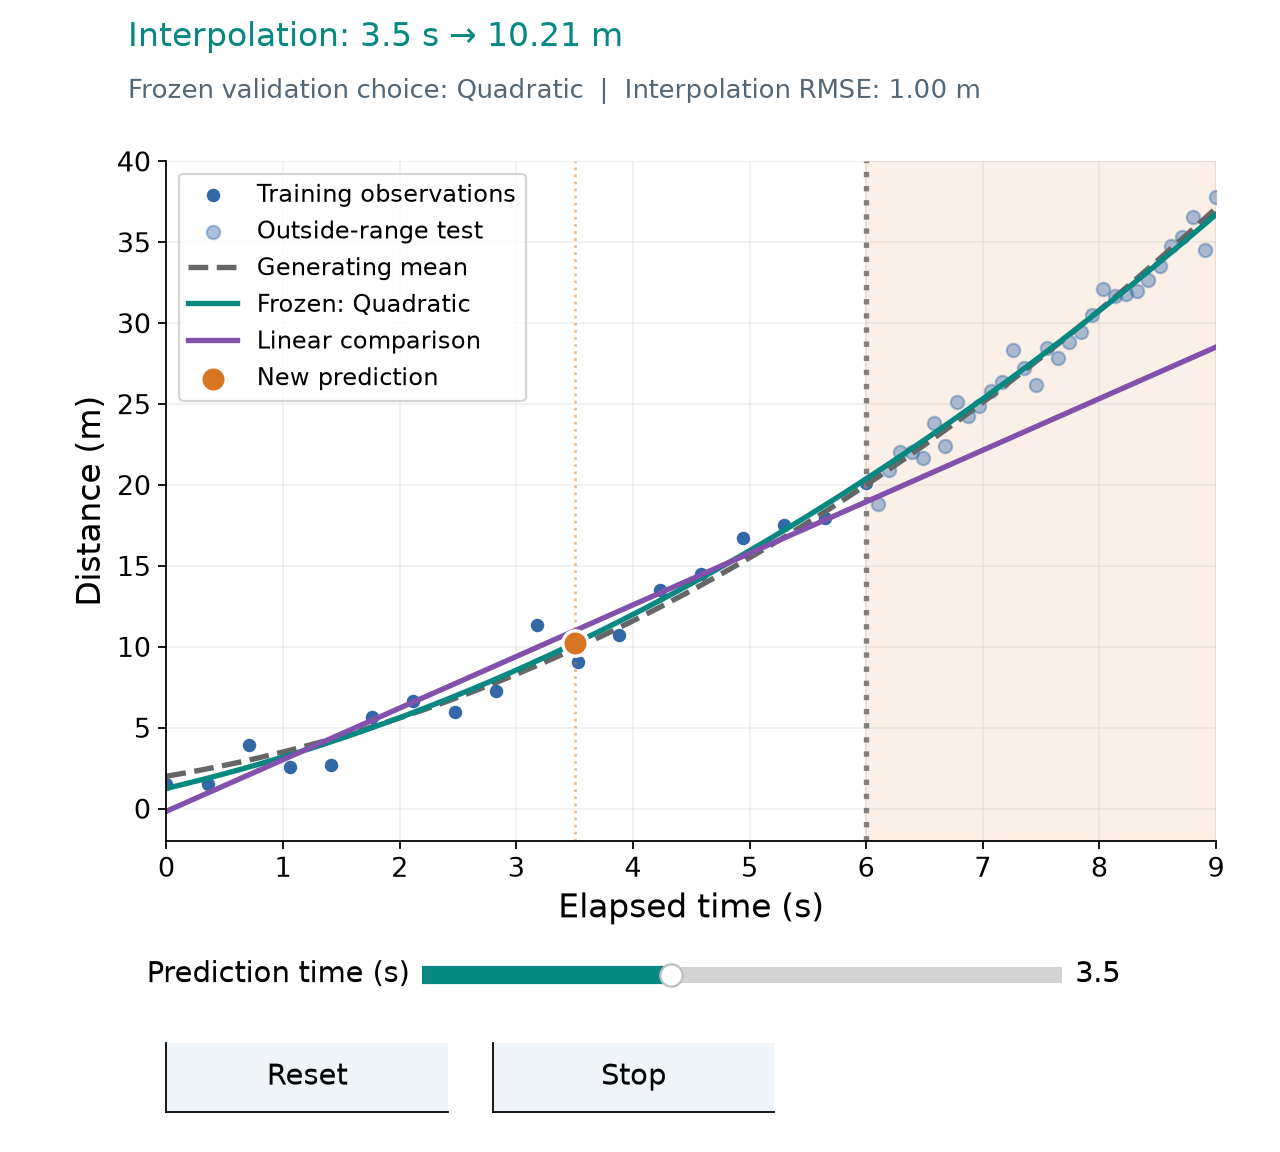

In [2]:
time_test_inside = np.linspace(0.07, 5.93, 61)
distance_test_inside = cart_mean(time_test_inside) + rng_cart.normal(0, 0.9, 61)
time_test_outside = np.linspace(6.1, 9, 31)
distance_test_outside = cart_mean(time_test_outside) + rng_cart.normal(0, 0.9, 31)

cart_test_rows = []
for name, model in cart_models.items():
    for region, time, distance in [
        ("Interpolation", time_test_inside, distance_test_inside),
        ("Extrapolation", time_test_outside, distance_test_outside),
    ]:
        cart_test_rows.append({"Model": name, "Region": region,
                               **metrics(distance, model.predict(time[:, None]))})
cart_test_table = pd.DataFrame(cart_test_rows)
print("Test RMSE in metres. Large errors are shown in full.")
display(cart_test_table.set_index(["Model", "Region"])[["RMSE"]].round(3))


extended_time = np.linspace(0, 9, 400)
selected_test_errors = cart_test_table[cart_test_table["Model"] == selected_name].set_index("Region")


def render_cart_query(view, query_time):
    prediction = float(selected_cart.predict([[query_time]])[0])
    region = "Interpolation" if 0 <= query_time <= 6 else "Extrapolation"
    ax = view.ax
    ax.axvspan(6, 9, color=ORANGE, alpha=.10)
    ax.axvline(6, color="0.5", linestyle=":")
    ax.scatter(time_train, distance_train, color=BLUE, edgecolor="white", s=50, label="Training observations")
    ax.scatter(time_test_outside, distance_test_outside, color=BLUE, s=36,
               alpha=.4, label="Outside-range test")
    ax.plot(extended_time, cart_mean(extended_time), "--", color="0.4", label="Generating mean")
    ax.plot(extended_time, selected_cart.predict(extended_time[:, None]), color=TEAL,
            label=f"Frozen: {selected_name}")
    ax.plot(extended_time, cart_models["Linear"].predict(extended_time[:, None]),
            color=PURPLE, label="Linear comparison")
    ax.scatter([query_time], [prediction], s=130, color=ORANGE, edgecolor="white", linewidth=1.5,
               label="New prediction", zorder=6)
    ax.set(xlabel="Elapsed time (s)", ylabel="Distance (m)", xlim=(0, 9), ylim=(-2, 40))
    ax.axvline(query_time, color=ORANGE, linestyle=":", linewidth=1.2, alpha=.5)
    ax.legend(loc="upper left")
    view.status.set_text(f"{region}: {query_time:.1f} s → {prediction:.2f} m")
    view.detail.set_text(f"Frozen validation choice: {selected_name}  |  {region} RMSE: {selected_test_errors.loc[region, 'RMSE']:.2f} m")
    return {"prediction": prediction, "region": region, "model": selected_cart}


cart_query_demo = RegressionExplorer("cart_query", render_cart_query, [
    ("query_time", "Prediction time (s)", 0, 9, 3.5, .1, "%0.1f"),
])
cart_query_demo.start()

Repeated multiplication can make a high-degree term grow quickly outside the measured range. A degree-12 curve can therefore fit the training dots closely and still make extreme predictions later. Ridge reduces that problem in this example but cannot guarantee a sensible continuation.

The quadratic predicts well because the simulated cart keeps following the same motion. A cart that starts braking after 6 s would break that assumption. A good fit to earlier motion cannot establish what the cart will do next.